In [1]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import os

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/Store-Sales-Forecasting"
PROCESSED_PATH = f"{PROJECT_PATH}/Data/Processed"
IMAGES_PATH = f"{PROJECT_PATH}/Images"

os.makedirs(IMAGES_PATH, exist_ok=True)

master_df = pd.read_csv(
    f"{PROCESSED_PATH}/master_dataset.csv",
    parse_dates=["date"]
)

print("Master dataset loaded successfully.")
print("Shape:", master_df.shape)
master_df.head()

Mounted at /content/drive
Master dataset loaded successfully.
Shape: (3000888, 18)


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico,holiday_type,holiday_locale,holiday_description,is_transferred,is_holiday,transactions_missing
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,93.14,Holiday,National,Primer dia del ano,False,1,1
1,1194,2013-01-01,42,CELEBRATION,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,Holiday,National,Primer dia del ano,False,1,1
2,1193,2013-01-01,42,BREAD/BAKERY,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,Holiday,National,Primer dia del ano,False,1,1
3,1192,2013-01-01,42,BOOKS,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,Holiday,National,Primer dia del ano,False,1,1
4,1191,2013-01-01,42,BEVERAGES,0.0,0,Cuenca,Azuay,D,2,0.0,93.14,Holiday,National,Primer dia del ano,False,1,1


In [2]:
print("Date range:")
print("Start:", master_df["date"].min())
print("End:", master_df["date"].max())

print("\nMissing values:")
print(master_df.isnull().sum()[master_df.isnull().sum() > 0])

print("\nColumns:")
print(master_df.columns.tolist())

Date range:
Start: 2013-01-01 00:00:00
End: 2017-08-15 00:00:00

Missing values:
Series([], dtype: int64)

Columns:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'transactions', 'dcoilwtico', 'holiday_type', 'holiday_locale', 'holiday_description', 'is_transferred', 'is_holiday', 'transactions_missing']


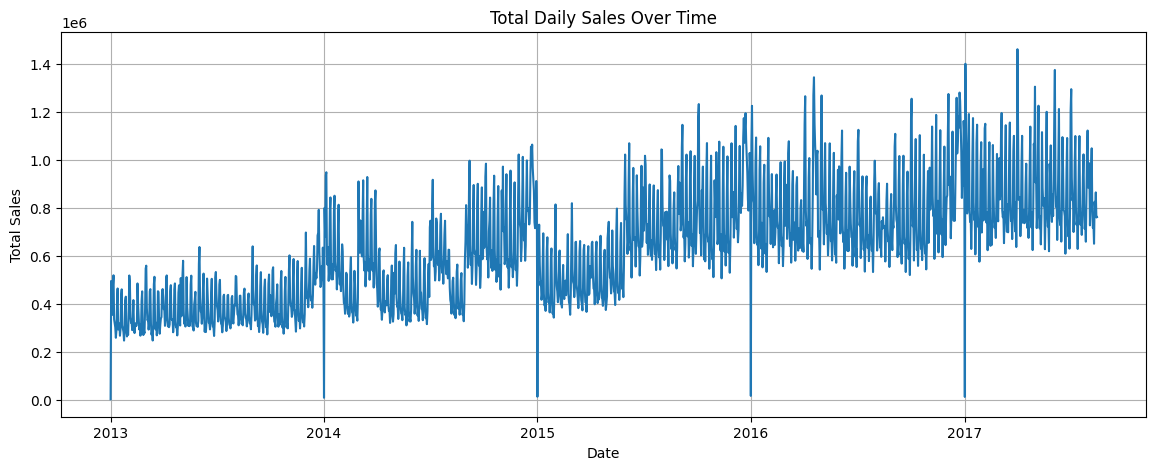

In [3]:
daily_sales = master_df.groupby("date", as_index=False)["sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.savefig(f"{IMAGES_PATH}/daily_sales_trend.png", bbox_inches="tight")
plt.show()

### Observation
Daily sales fluctuate over time, with visible peaks that may be linked to promotions, holidays, weekends, and seasonal demand.

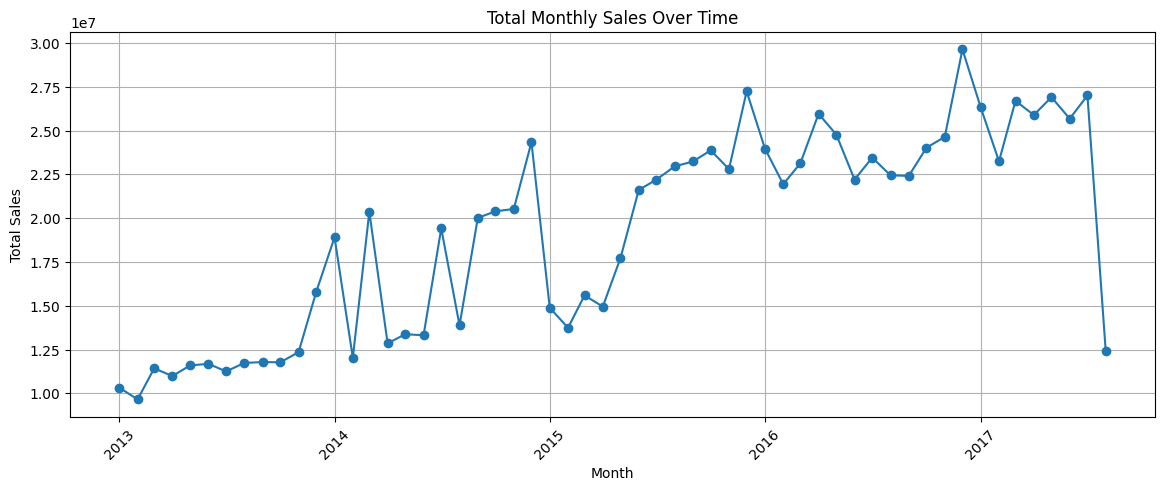

In [4]:
# Create month column
master_df["year_month"] = master_df["date"].dt.to_period("M").astype(str)

# Calculate total monthly sales
monthly_sales = master_df.groupby("year_month", as_index=False)["sales"].sum()

# Convert year_month back to date for plotting
monthly_sales["year_month"] = pd.to_datetime(monthly_sales["year_month"])

# Plot monthly sales
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales["year_month"], monthly_sales["sales"], marker="o")
plt.title("Total Monthly Sales Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.xticks(rotation=45)
plt.savefig(f"{IMAGES_PATH}/monthly_sales_trend.png", bbox_inches="tight")
plt.show()

### Observation
Monthly sales provide a clearer view of the overall growth and seasonal patterns. The trend will help identify high-demand and low-demand periods for forecasting.

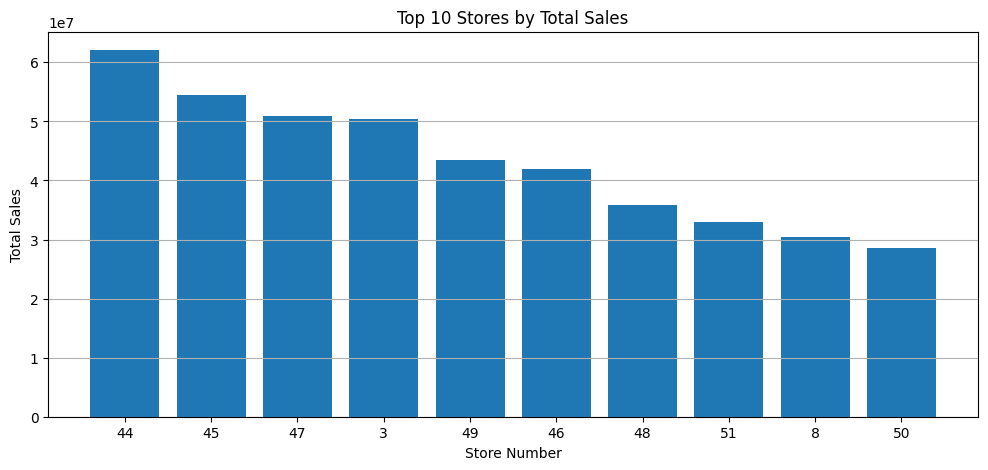

,store_nbr,sales
43,44,6.208755e+07
44,45,5.449801e+07
46,47,5.094831e+07
2,3,5.048191e+07
48,49,4.342010e+07
45,46,4.189606e+07
47,48,3.593313e+07
50,51,3.291149e+07
7,8,3.049429e+07
49,50,2.865302e+07


In [5]:
# Total sales by store
store_sales = (
    master_df.groupby("store_nbr", as_index=False)["sales"]
    .sum()
    .sort_values("sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
plt.bar(store_sales["store_nbr"].astype(str), store_sales["sales"])
plt.title("Top 10 Stores by Total Sales")
plt.xlabel("Store Number")
plt.ylabel("Total Sales")
plt.grid(axis="y")
plt.savefig(f"{IMAGES_PATH}/top_10_stores_sales.png", bbox_inches="tight")
plt.show()

store_sales

### Observation
The chart identifies the top 10 stores by total sales. Store-level differences may be influenced by store location, type, cluster, customer traffic, and promotions.


Store 44 generated the highest total sales, followed by Stores 45 and 47. Sales vary considerably across stores, so store-related features should be included in the forecasting model.

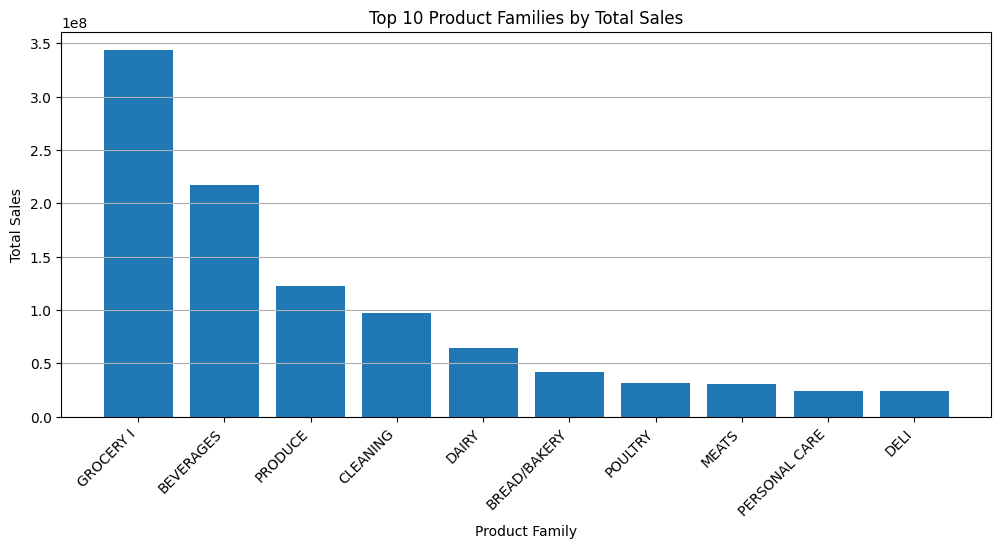

,family,sales
12,GROCERY I,3.434627e+08
3,BEVERAGES,2.169545e+08
30,PRODUCE,1.227047e+08
7,CLEANING,9.752129e+07
8,DAIRY,6.448771e+07
5,BREAD/BAKERY,4.213395e+07
28,POULTRY,3.187600e+07
24,MEATS,3.108647e+07
25,PERSONAL CARE,2.459205e+07
9,DELI,2.411032e+07


In [6]:
# Top 10 product families by total sales
family_sales = (
    master_df.groupby("family", as_index=False)["sales"]
    .sum()
    .sort_values("sales", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 5))
plt.bar(family_sales["family"], family_sales["sales"])
plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Product Family")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.savefig(f"{IMAGES_PATH}/top_10_product_families.png", bbox_inches="tight")
plt.show()

family_sales

### Observation
The chart highlights the product families that contribute the most to total sales. These high-performing categories are important for inventory planning and sales forecasting.

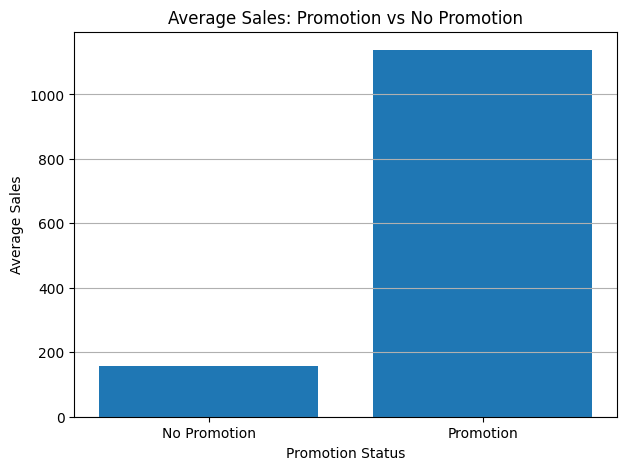

,is_on_promotion,sales,promotion_status
0,False,158.246681,No Promotion
1,True,1137.693730,Promotion


In [7]:
# Compare average sales for promotion vs no promotion
promotion_sales = (
    master_df.assign(is_on_promotion=master_df["onpromotion"] > 0)
    .groupby("is_on_promotion", as_index=False)["sales"]
    .mean()
)

promotion_sales["promotion_status"] = promotion_sales["is_on_promotion"].map({
    False: "No Promotion",
    True: "Promotion"
})

plt.figure(figsize=(7, 5))
plt.bar(promotion_sales["promotion_status"], promotion_sales["sales"])
plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Sales")
plt.grid(axis="y")
plt.savefig(f"{IMAGES_PATH}/promotion_vs_sales.png", bbox_inches="tight")
plt.show()

promotion_sales

### Observation
This chart compares average sales when at least one item is on promotion with average sales when no items are on promotion. It helps assess whether promotions are associated with higher sales.

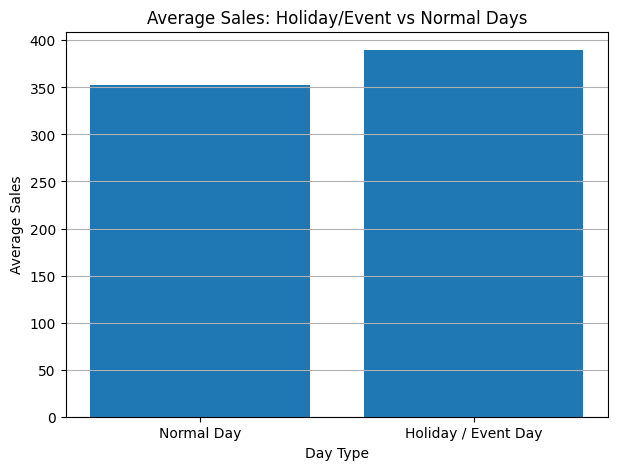

,is_holiday,sales,day_type
0,0,352.159181,Normal Day
1,1,389.692123,Holiday / Event Day


In [8]:
holiday_sales = (
    master_df.groupby("is_holiday", as_index=False)["sales"]
    .mean()
)

holiday_sales["day_type"] = holiday_sales["is_holiday"].map({
    0: "Normal Day",
    1: "Holiday / Event Day"
})

plt.figure(figsize=(7, 5))
plt.bar(holiday_sales["day_type"], holiday_sales["sales"])
plt.title("Average Sales: Holiday/Event vs Normal Days")
plt.xlabel("Day Type")
plt.ylabel("Average Sales")
plt.grid(axis="y")
plt.savefig(f"{IMAGES_PATH}/holiday_vs_normal_sales.png", bbox_inches="tight")
plt.show()

holiday_sales


### Observation
This comparison shows whether sales differ on holiday or event dates compared with normal days. The `is_holiday` feature may help the model capture calendar-related demand patterns.

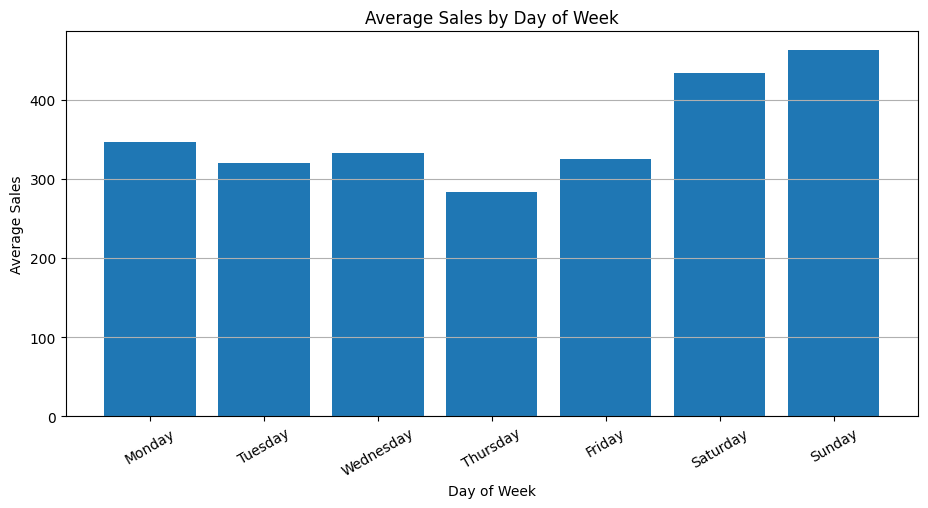

,day_of_week,sales
1,Monday,346.544732
5,Tuesday,319.823843
6,Wednesday,332.909401
4,Thursday,283.540517
0,Friday,325.238138
2,Saturday,433.336472
3,Sunday,463.085366


In [9]:
# Create day-of-week column
master_df["day_of_week"] = master_df["date"].dt.day_name()

# Set the correct weekday order
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Average sales by day of week
weekday_sales = (
    master_df.groupby("day_of_week", as_index=False)["sales"]
    .mean()
)

weekday_sales["day_of_week"] = pd.Categorical(
    weekday_sales["day_of_week"],
    categories=weekday_order,
    ordered=True
)

weekday_sales = weekday_sales.sort_values("day_of_week")

plt.figure(figsize=(11, 5))
plt.bar(weekday_sales["day_of_week"], weekday_sales["sales"])
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.savefig(f"{IMAGES_PATH}/average_sales_by_day_of_week.png", bbox_inches="tight")
plt.show()

weekday_sales

### Observation
Average sales are highest on weekends, especially Sunday and Saturday, while Thursday has the lowest average sales. This confirms weekly seasonality and shows that day-of-week will be a useful forecasting feature.


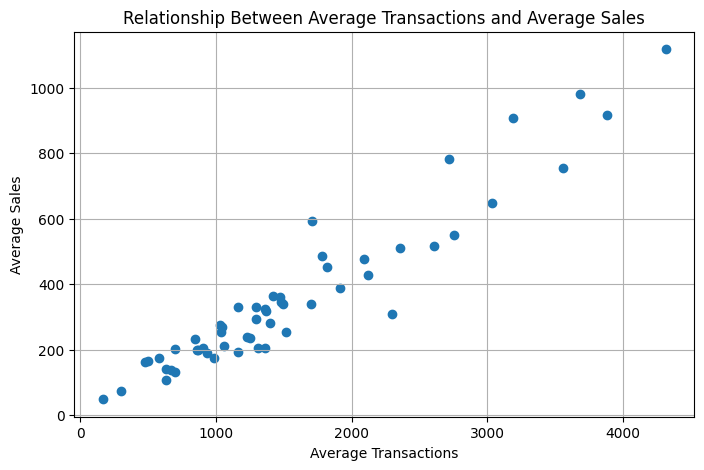

In [10]:
# Average sales and transactions by store
store_performance = (
    master_df.groupby("store_nbr", as_index=False)
    .agg(
        average_sales=("sales", "mean"),
        average_transactions=("transactions", "mean")
    )
)

plt.figure(figsize=(8, 5))
plt.scatter(
    store_performance["average_transactions"],
    store_performance["average_sales"]
)
plt.title("Relationship Between Average Transactions and Average Sales")
plt.xlabel("Average Transactions")
plt.ylabel("Average Sales")
plt.grid(True)
plt.savefig(
    f"{IMAGES_PATH}/transactions_vs_sales.png",
    bbox_inches="tight"
)
plt.show()

### Observation
Stores with higher average transaction volumes generally have higher average sales. This positive relationship suggests that the `transactions` feature can contribute useful information to the forecasting model.